<a href="https://colab.research.google.com/github/1Bur1/clothes-image-Classifier/blob/main/03_bonus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 Bonus Tasks

This notebook covers the **two bonus items** from the project brief (+4 pts total).

| Bonus | Task | Points |
|---|---|---|
| 1 | Data Augmentation — train with rotation/shift, compare accuracy with/without | +2 |
| 2 | Dashboard — 4 charts in one Matplotlib figure | +2 |

**Prerequisite:** Run `01_train.ipynb` first so the data can load.

## Setup & Imports

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

os.makedirs('../reports', exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)


### FashionClassifier Class

Reused from `01_train.ipynb` — same architecture, same data split.

In [11]:
class FashionClassifier:

    CLASS_NAMES = [
        'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot' ]

    def __init__(self, seed=42):
        self.seed = seed
        np.random.seed(seed)
        tf.random.set_seed(seed)
        self.X_train = self.X_val = self.X_test = None
        self.y_train = self.y_val = self.y_test = None
        self.model   = None
        self.history = None
        print(f'FashionClassifier ready (seed={seed})')

    def load_data(self):

        (X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()

        # Step 1 -- combine all 70,000 images
        X_all = np.concatenate([X_tr, X_te], axis=0)
        y_all = np.concatenate([y_tr, y_te], axis=0)

        # Step 2 & 3 -- normalise + channel dim
        X_all = (X_all / 255.0).reshape(-1, 28, 28, 1)

        # Step 4 -- shuffle with fixed seed
        np.random.seed(self.seed)
        idx   = np.random.permutation(len(X_all))
        X_all = X_all[idx]
        y_all = y_all[idx]

        # Step 5 -- split 70 / 15 / 15
        n      = len(X_all)            # 70,000
        n_test = int(n * 0.15)         # 10,500
        n_val  = int(n * 0.15)         # 10,500
        # train = 70,000 - 10,500 - 10,500 = 49,000

        self.X_test,  self.y_test  = X_all[:n_test],              y_all[:n_test]
        self.X_val,   self.y_val   = X_all[n_test:n_test+n_val],  y_all[n_test:n_test+n_val]
        self.X_train, self.y_train = X_all[n_test+n_val:],        y_all[n_test+n_val:]

        print('Data loaded (full 70,000 images, 70/15/15 split):')
        print(f'  Training   : {self.X_train.shape}  ({len(self.X_train):,} images - 70%)')
        print(f'  Validation : {self.X_val.shape}  ({len(self.X_val):,} images - 15%)')
        print(f'  Test       : {self.X_test.shape}  ({len(self.X_test):,} images - 15%) <- locked until Phase 3')
        return self
    def build_model(self, dropout=0.3):
        np.random.seed(self.seed)
        tf.random.set_seed(self.seed)
        mdl = [
            layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
            layers.MaxPooling2D((2,2)),
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D((2,2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
        ]
        if dropout is not None:
            mdl.append(layers.Dropout(dropout))
        mdl.append(layers.Dense(10, activation='softmax'))
        self.model = keras.Sequential(mdl, name='fashion_cnn')
        self.model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
        print(f'Model built (dropout={dropout})')
        return self

    def train(self, epochs=5, batch_size=32):
        print(f'Training for {epochs} epochs...')
        self.history = self.model.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_val, self.y_val),
            epochs=epochs, batch_size=batch_size, verbose=1)
        best = max(self.history.history['val_accuracy'])
        print(f'Best val accuracy: {best*100:.2f}%')
        return self




---
## BONUS 1 (+2 pts) — Data Augmentation

**What is data augmentation?**  
Instead of collecting new photos, we randomly transform existing training images each epoch:

| Parameter | What it does |
|---|---|
| `rotation_range=10` | Rotate image up to 10 degrees |
| `width_shift_range=0.1` | Shift image left/right up to 10% |
| `height_shift_range=0.1` | Shift image up/down up to 10% |

The model sees a slightly different version of each image every epoch.  
This reduces overfitting and helps the model generalise.

**Plan:** Train the same CNN twice — only the augmentation changes.

### Step 1 — Train WITHOUT Augmentation (reference run)

In [6]:
clf = FashionClassifier(seed=42)
clf.load_data()
clf.build_model(dropout=0.3)
clf.train(epochs=5, batch_size=32)

history_no_aug = clf.history


FashionClassifier ready (seed=42)
Data loaded (full 70,000 images, 70/15/15 split):
  Training   : (49000, 28, 28, 1)  (49,000 images - 70%)
  Validation : (10500, 28, 28, 1)  (10,500 images - 15%)
  Test       : (10500, 28, 28, 1)  (10,500 images - 15%) <- locked until Phase 3
Model built (dropout=0.3)
Training for 5 epochs...
Epoch 1/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.8132 - loss: 0.5153 - val_accuracy: 0.8699 - val_loss: 0.3489
Epoch 2/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.8781 - loss: 0.3408 - val_accuracy: 0.8889 - val_loss: 0.2980
Epoch 3/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.8938 - loss: 0.2917 - val_accuracy: 0.8919 - val_loss: 0.2802
Epoch 4/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9047 - loss: 0.2604 - val_accuracy: 0.9067 - val_loss: 0.2562
Epoch 5/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9136 - loss: 0.2337 - val_accuracy: 0.9036 - val_loss: 0.2645
Best val accura

### Step 2 — Train WITH Augmentation

`ImageDataGenerator` generates augmented batches on the fly during training.  
The original images on disk are never changed — augmentation happens in memory.

In [7]:
# Rebuild same architecture fresh
clf.build_model(dropout=0.3)

# Create the augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Train with augmented batches
history_aug = clf.model.fit(
    datagen.flow(clf.X_train, clf.y_train, batch_size=32),
    validation_data=(clf.X_val, clf.y_val),
    epochs=5,
    verbose=1
)
print(f'Best val accuracy (with aug): {max(history_aug.history["val_accuracy"])*100:.2f}%')


Model built (dropout=0.3)
Epoch 1/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7265 - loss: 0.7269 - val_accuracy: 0.8064 - val_loss: 0.4829
Epoch 2/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.7949 - loss: 0.5373 - val_accuracy: 0.8527 - val_loss: 0.3947
Epoch 3/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.8200 - loss: 0.4755 - val_accuracy: 0.8590 - val_loss: 0.3720
Epoch 4/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.8378 - loss: 0.4355 - val_accuracy: 0.8675 - val_loss: 0.3421
Epoch 5/5
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.8467 - loss: 0.4101 - val_accuracy: 0.8832 - val_loss: 0.3046
Best val accuracy (with aug): 88.32%


### Step 3 — Compare Results

In [8]:
no_aug_acc = max(history_no_aug.history['val_accuracy'])
aug_acc    = max(history_aug.history['val_accuracy'])
diff       = aug_acc - no_aug_acc

print('=' * 46)
print('  DATA AUGMENTATION COMPARISON')
print('=' * 46)
print(f'  Without augmentation : {no_aug_acc*100:.2f}%')
print(f'  With augmentation    : {aug_acc*100:.2f}%')
print(f'  Difference           : {diff*100:+.2f}%')
print('=' * 46)
if diff > 0:
    print('  Augmentation IMPROVED accuracy.')
elif diff < 0:
    print('  Augmentation slightly reduced accuracy at 5 epochs.')
    print('  More epochs with augmentation would likely close this gap.')
else:
    print('  No difference at 5 epochs.')


  DATA AUGMENTATION COMPARISON
  Without augmentation : 90.67%
  With augmentation    : 88.32%
  Difference           : -2.34%
  Augmentation slightly reduced accuracy at 5 epochs.
  More epochs with augmentation would likely close this gap.


---
## BONUS 2 (+2 pts) — Dashboard

One figure with **4 subplots** — all key results at a glance.

| Chart | What it shows |
|---|---|
| 1 (top-left) | Validation accuracy — No Aug vs With Aug |
| 2 (top-right) | Validation loss — No Aug vs With Aug |
| 3 (bottom-left) | Class distribution — samples per class in training set |
| 4 (bottom-right) | Sample images — one per class from validation set |

Saved to `reports/dashboard.png`.

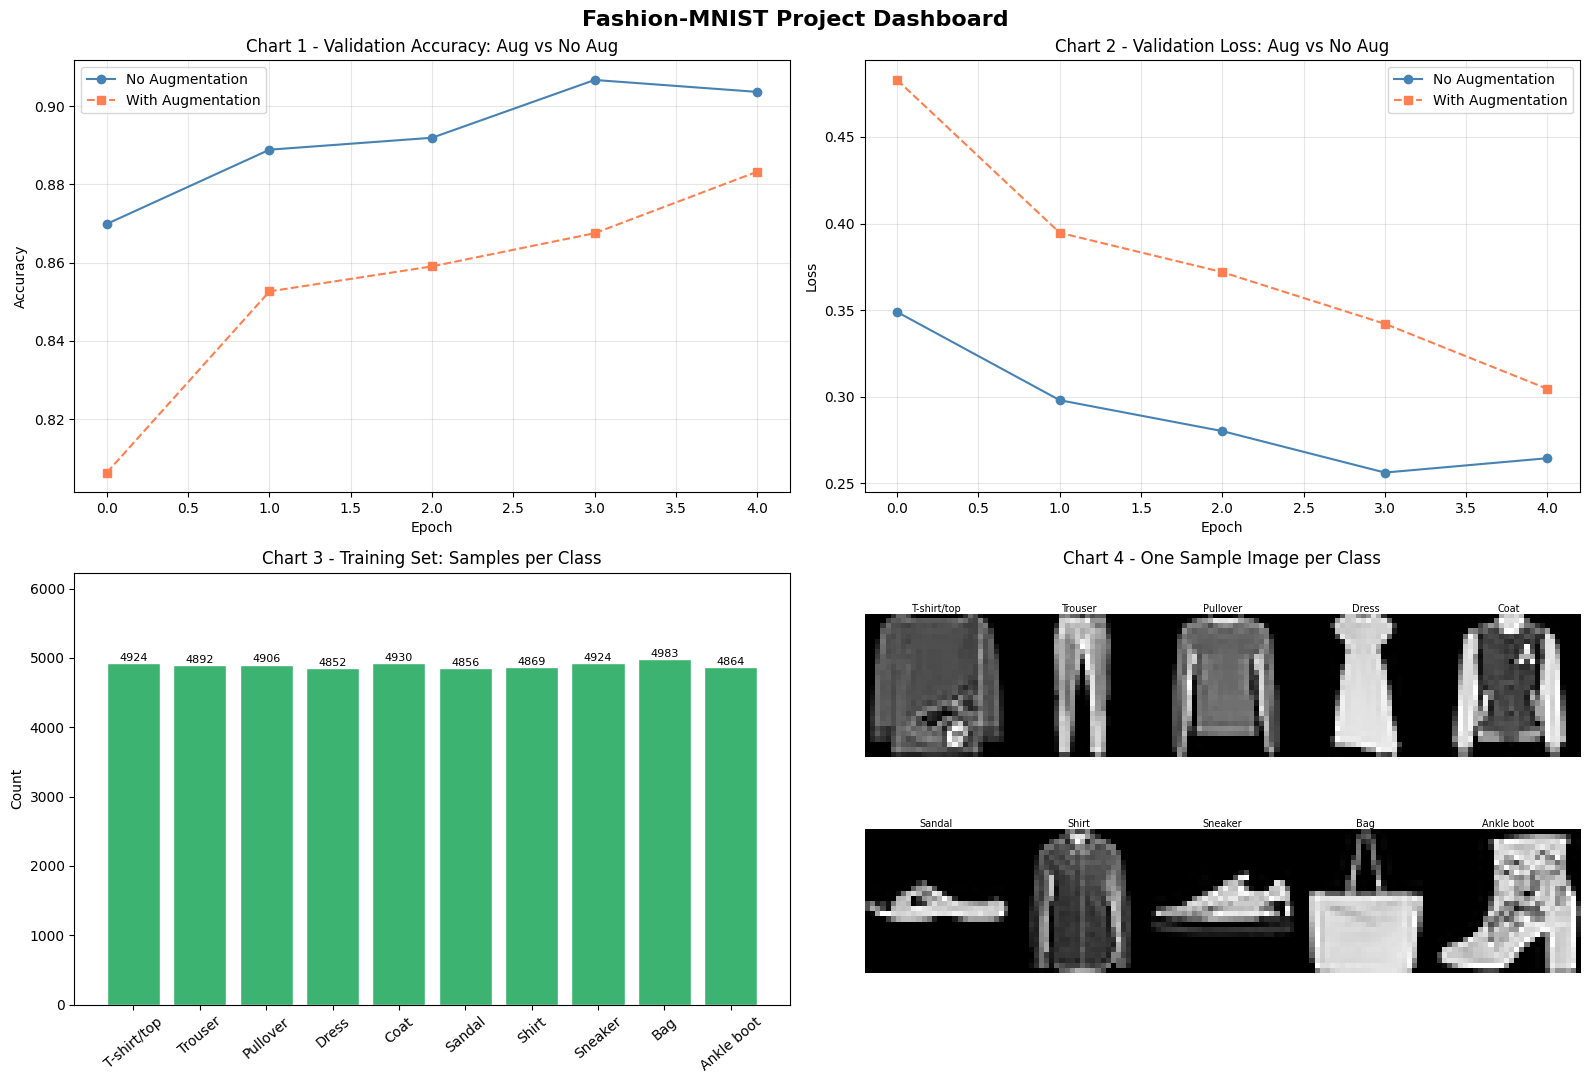

In [9]:
CLASS_NAMES = FashionClassifier.CLASS_NAMES

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Fashion-MNIST Project Dashboard', fontsize=16, fontweight='bold')

# Chart 1 — Validation Accuracy
ax = axes[0, 0]
ax.plot(history_no_aug.history['val_accuracy'], marker='o', label='No Augmentation', color='steelblue')
ax.plot(history_aug.history['val_accuracy'],    marker='s', label='With Augmentation', color='coral', linestyle='--')
ax.set_title('Chart 1 - Validation Accuracy: Aug vs No Aug')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# Chart 2 — Validation Loss
ax = axes[0, 1]
ax.plot(history_no_aug.history['val_loss'], marker='o', label='No Augmentation', color='steelblue')
ax.plot(history_aug.history['val_loss'],    marker='s', label='With Augmentation', color='coral', linestyle='--')
ax.set_title('Chart 2 - Validation Loss: Aug vs No Aug')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Chart 3 — Class Distribution
ax = axes[1, 0]
_, counts = np.unique(clf.y_train, return_counts=True)
bars = ax.bar(CLASS_NAMES, counts, color='mediumseagreen', edgecolor='white')
ax.set_title('Chart 3 - Training Set: Samples per Class')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts) * 1.25)
ax.tick_params(axis='x', rotation=40)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=8)

# Chart 4 — Sample images (one per class, 2 rows x 5 cols)
ax = axes[1, 1]
ax.axis('off')
ax.set_title('Chart 4 - One Sample Image per Class')
for class_idx in range(10):
    row = class_idx // 5
    col = class_idx % 5
    inset = ax.inset_axes([col/5, 1 - (row+1)/2, 1/5, 0.48])
    idx = np.where(clf.y_val == class_idx)[0][0]
    inset.imshow(clf.X_val[idx].squeeze(), cmap='gray')
    inset.set_title(CLASS_NAMES[class_idx], fontsize=7, pad=1)
    inset.axis('off')

plt.tight_layout()
plt.savefig('../reports/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Bonus Tasks Complete

| Bonus | Status | Points |
|---|---|---|
| 1 — Data Augmentation | Done — comparison table printed above | +2 |
| 2 — Dashboard | Done — `reports/dashboard.png` saved | +2 |

Total bonus points earned: **+4 pts**  
Proceed to `report.md` for Phase 4.